<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


C:\Users\Dell\AppData\Local\Temp\ipykernel_10036\412146434.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education'].fillna(df['Education'].mode()[0], inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10036\412146434.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

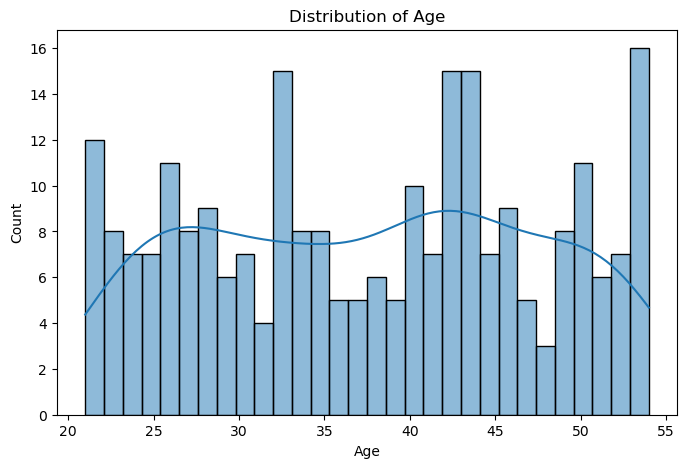

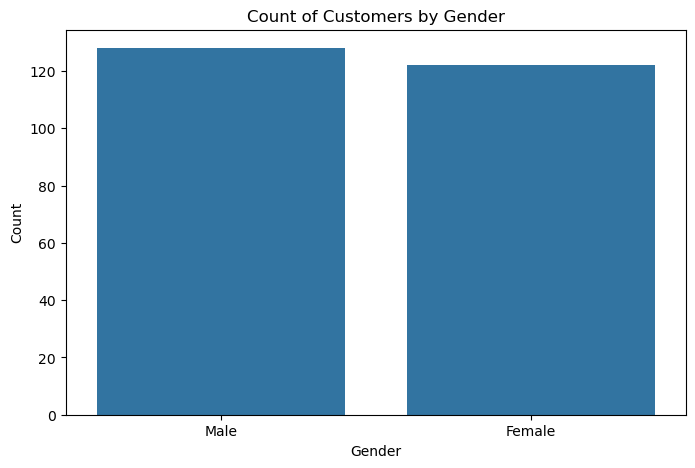

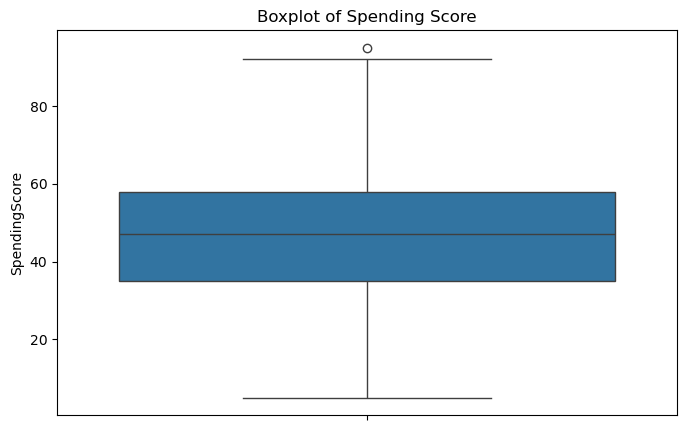

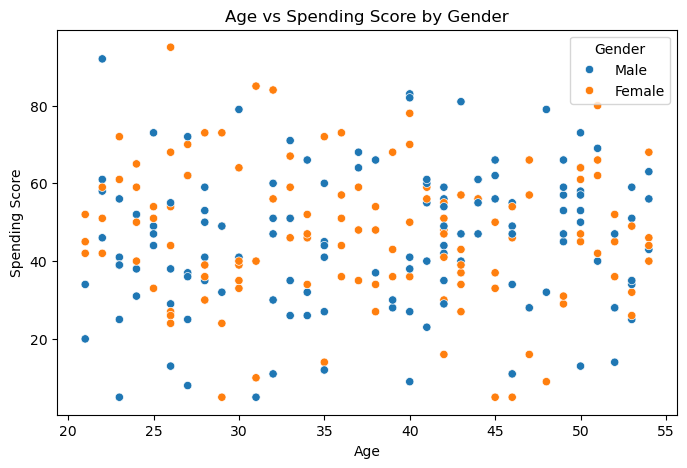

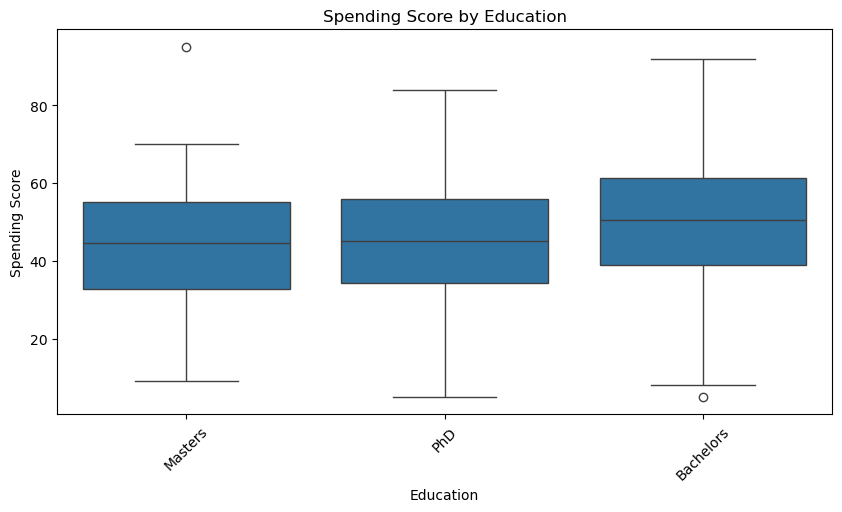

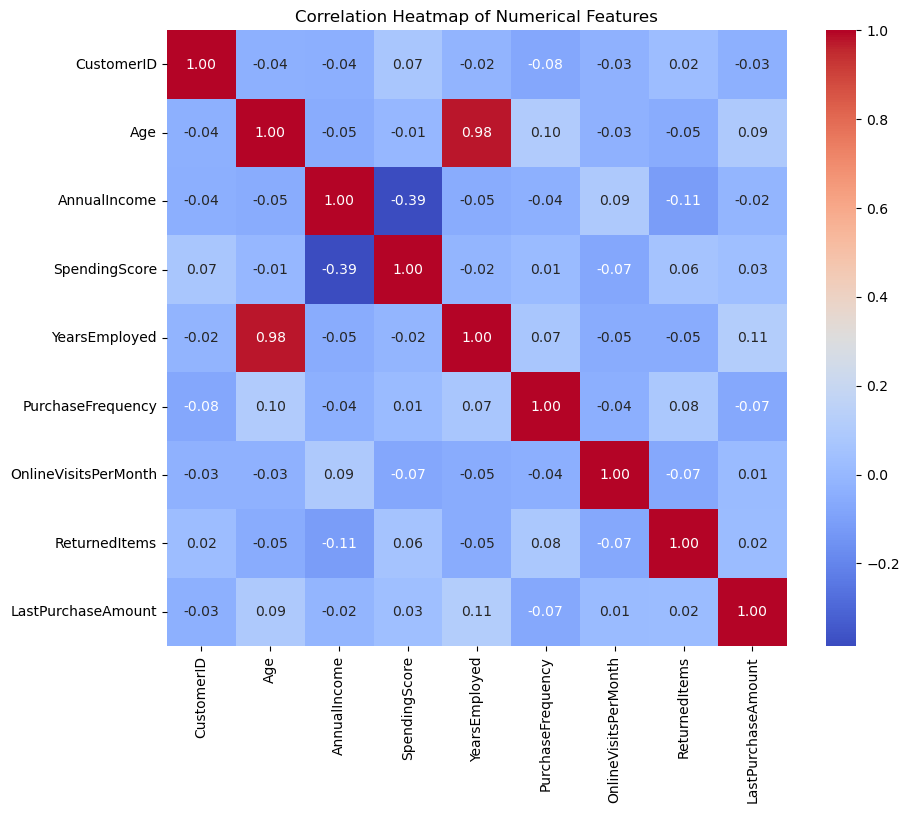

In [ ]:
# Phase 1: The Detective Work (Setup & Inspection)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('customer_analytics.csv')

# Inspect the dataset
df.head()
df.info()
df.describe()

# Phase 2: The Cleanup (Data Preprocessing)

# Check for missing values
df.isnull().sum()

# Handle missing values
df['Education'].fillna(df['Education'].mode()[0], inplace=True)
df['AnnualIncome'].fillna(df['AnnualIncome'].mean(), inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Phase 3: The Deep Dive (Univariate & Bivariate Analysis)

# Histogram for Age
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Bar chart for Gender
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', data=df)
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Boxplot for SpendingScore
plt.figure(figsize=(8,5))
sns.boxplot(y='SpendingScore', data=df)
plt.title('Boxplot of Spending Score')
plt.show()

# Scatter plot: Age vs SpendingScore colored by Gender
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='SpendingScore', data=df, hue='Gender')
plt.title('Age vs Spending Score by Gender')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.show()

# Boxplot: SpendingScore by Education
plt.figure(figsize=(10,5))
sns.boxplot(x='Education', y='SpendingScore', data=df)
plt.title('Spending Score by Education')
plt.xlabel('Education')
plt.ylabel('Spending Score')
plt.xticks(rotation=45)
plt.show()

# Phase 4: The Big Picture (Multivariate & Storytelling)

# Select numeric columns only
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()